In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# 1. CRIANDO O DATAFRAME PARA O EXERCÍCIO
data = {
    'id_sensor': [101, 102, 103, 104, 101, 105, 106, 107, 108, 109],
    'localizacao': ['Setor A', 'Setor B', 'Setor A', 'Setor C', 'Setor A', 'Setor B', 'Setor C', 'Setor A', np.nan, 'Setor B'],
    'consumo_kwh': [150.5, 3200.0, 150.5, 2100.0, 150.5, np.nan, 4500.0, 120.0, 5000.0, 250.0],
    'temperatura_operacao': [25.4, 65.2, 25.4, np.nan, 25.4, 40.0, 85.0, 22.0, 90.0, 30.5],
    'status': ['Ativo', 'Alerta', 'Ativo', 'Inativo', 'Ativo', 'Ativo', 'Alerta', 'Ativo', 'Critico', 'Inativo']
}

df = pd.DataFrame(data)

In [11]:
df

,id_sensor,localizacao,consumo_kwh,temperatura_operacao,status
0,101,Setor A,150.5,25.4,Ativo
1,102,Setor B,3200.0,65.2,Alerta
2,103,Setor A,150.5,25.4,Ativo
3,104,Setor C,2100.0,NaN,Inativo
4,101,Setor A,150.5,25.4,Ativo
5,105,Setor B,NaN,40.0,Ativo
6,106,Setor C,4500.0,85.0,Alerta
7,107,Setor A,120.0,22.0,Ativo
8,108,NaN,5000.0,90.0,Critico
9,109,Setor B,250.0,30.5,Inativo


limpeza

In [12]:
df['localizacao'] = df['localizacao'].fillna(df['localizacao'].mode())
df['consumo_kwh'] = df['consumo_kwh'].fillna(df['consumo_kwh'].median())
df['consumo_kwh'] = df['consumo_kwh'].fillna(df['consumo_kwh'].median())
df['temperatura_operacao'] = df['temperatura_operacao'].fillna(df['temperatura_operacao'].median())


codificação

In [13]:
df_encoded = pd.get_dummies(df,columns=['localizacao','status']) #one-hot

normalização

In [14]:
scaler = MinMaxScaler()
df_norm = pd.DataFrame(
    scaler.fit_transform(df_encoded),
    columns=df_encoded.columns
)

plotando histogramas

In [15]:
import matplotlib.pyplot as plt

In [16]:
df_norm

,id_sensor,consumo_kwh,temperatura_operacao,localizacao_Setor A,localizacao_Setor B,localizacao_Setor C,status_Alerta,status_Ativo,status_Critico,status_Inativo
0,0.000,0.006250,0.050000,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.125,0.631148,0.635294,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,0.250,0.006250,0.050000,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.375,0.405738,0.125000,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.000,0.006250,0.050000,1.0,0.0,0.0,0.0,1.0,0.0,0.0
5,0.500,0.026639,0.264706,0.0,1.0,0.0,0.0,1.0,0.0,0.0
6,0.625,0.897541,0.926471,0.0,0.0,1.0,1.0,0.0,0.0,0.0
7,0.750,0.000000,0.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0
8,0.875,1.000000,1.000000,0.0,0.0,0.0,0.0,0.0,1.0,0.0
9,1.000,0.026639,0.125000,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [18]:
df_encoded

,id_sensor,consumo_kwh,temperatura_operacao,localizacao_Setor A,localizacao_Setor B,localizacao_Setor C,status_Alerta,status_Ativo,status_Critico,status_Inativo
0,101,150.5,25.4,True,False,False,False,True,False,False
1,102,3200.0,65.2,False,True,False,True,False,False,False
2,103,150.5,25.4,True,False,False,False,True,False,False
3,104,2100.0,30.5,False,False,True,False,False,False,True
4,101,150.5,25.4,True,False,False,False,True,False,False
5,105,250.0,40.0,False,True,False,False,True,False,False
6,106,4500.0,85.0,False,False,True,True,False,False,False
7,107,120.0,22.0,True,False,False,False,True,False,False
8,108,5000.0,90.0,False,False,False,False,False,True,False
9,109,250.0,30.5,False,True,False,False,False,False,True


In [27]:
df_encoded.shape

(10, 10)

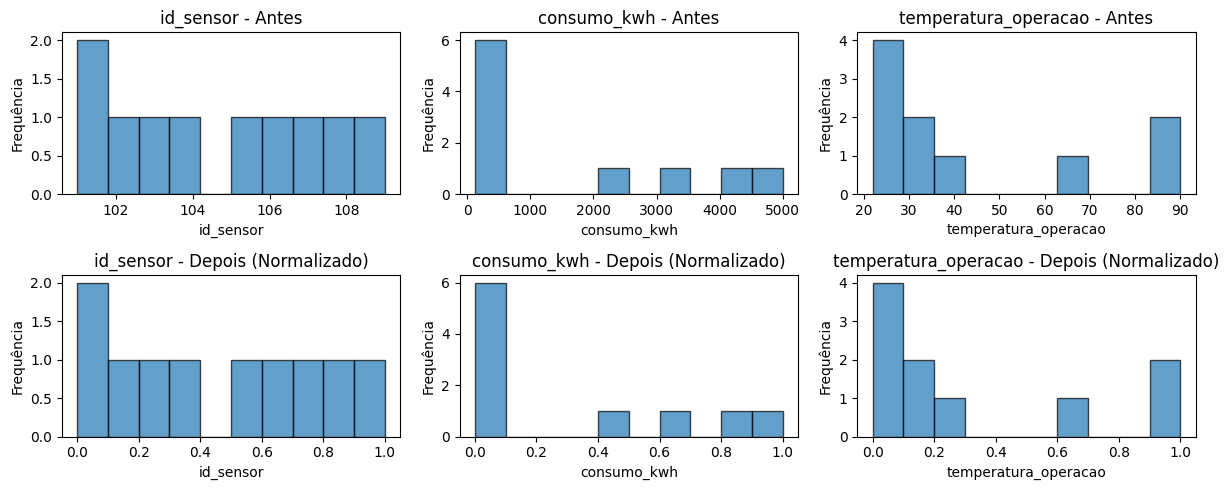

In [37]:
num_cols = df.select_dtypes(include=['number'])

plt.figure(figsize=(40,5))

for i, col in enumerate(num_cols): #Aqui você está percorrendo a lista de colunas numéricas (["idade", "salario"])

    # Antes da normalização
    plt.subplot(2, len(num_cols), i+1) #plt.subplot(linhas, colunas, posição)
    plt.hist(df_encoded[col], bins=10, alpha=0.7, edgecolor='black')
    plt.title(f"{col} - Antes")
    plt.xlabel(col)
    plt.ylabel("Frequência")

    # Depois da normalização
    plt.subplot(2, len(num_cols), i+1+len(num_cols))
    plt.hist(df_norm[col], bins=10, alpha=0.7, edgecolor='black')
    plt.title(f"{col} - Depois (Normalizado)")
    plt.xlabel(col)
    plt.ylabel("Frequência")

plt.tight_layout() #Ajusta o espaçamento automaticamente para que os títulos de baixo não fiquem em cima dos nomes dos eixos de cima.
plt.show()



